In [2]:
project_id = "ai-infra-jrt-1"
dataset_id = "fsimontecarlo_dataset_a12e3991"
table_id = "fsimontecarlo_table_daf6b934"

In [13]:
from google.cloud import bigquery
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

client = bigquery.Client(project=project_id)

df = client.query(f'''
SELECT ticker, cast(price AS FLOAT64) AS price, CAST(OFFSET as INTEGER) AS offset, start_date, end_date, iteration
FROM `{project_id}.{dataset_id}.{table_id}`,
UNNEST(simulation_results) as NUMERIC with OFFSET
WHERE  epoch_time IN
 # Get the latest simulation runs for each Ticker Symbol
(SELECT MAX(epoch_time)  FROM `{project_id}.{dataset_id}.{table_id}`  GROUP BY ticker)
'''
).to_dataframe()
# Display the data
df

,ticker,price,offset,start_date,end_date,iteration
0,MSFT,233.686691,0,2022-01-01,2023-01-01,49
1,MSFT,230.861370,1,2022-01-01,2023-01-01,49
2,MSFT,227.135281,2,2022-01-01,2023-01-01,49
3,MSFT,225.644692,3,2022-01-01,2023-01-01,49
4,MSFT,224.692473,4,2022-01-01,2023-01-01,49
...,...,...,...,...,...,...
989095,COST,365.125398,247,2022-01-01,2023-01-01,462
989096,COST,372.891287,248,2022-01-01,2023-01-01,462
989097,COST,379.662769,249,2022-01-01,2023-01-01,462
989098,COST,385.116302,250,2022-01-01,2023-01-01,462


###  Define a function to plot the data

In [5]:
def plot_ticker(t,df):

    dtf = df[(df.ticker==t) &(df.offset == 250)].price.describe(include=[np.float64], percentiles=[.05, .01, .001])
    cellText = []
    for v in dtf.values:
        cellText.append([v])
        
    pltf = df[df.ticker==t].pivot(index='offset', columns='iteration', values='price')
    
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(122)
    pltf.plot(legend=False, ax=ax1, xlabel='Time(days)', ylabel='US$', title=f"{ df[(df.ticker == t) & (df.offset == 0) & (df.iteration == 4)]}")
    ax2 = fig.add_subplot(121)
    font_size=10
    bbox=[0, 0, .5, 1]
    ax2.axis('off')
    mpl_table = ax2.table(cellText = cellText, rowLabels=dtf.index.values, bbox=bbox)
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(font_size)


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ticker(t, df):
    # 1. Prepare Data
    # Get stats for the final day (offset 250)
    final_day_data = df[(df.ticker == t) & (df.offset == 250)]
    dtf = final_day_data.price.describe(percentiles=[.05, .01, .001])
    
    cellText = [[v] for v in dtf.values]
    
    # Pivot for the line plot
    pltf = df[df.ticker == t].pivot(index='offset', columns='iteration', values='price')
    
    # 2. Setup Figure (3 columns now)
    fig = plt.figure(figsize=(15, 5))
    
    # AX1: The Table (Left)
    ax1 = fig.add_subplot(131)
    ax1.axis('off')
    mpl_table = ax1.table(cellText=cellText, rowLabels=dtf.index.values, bbox=[0, 0, 0.7, 1])
    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(10)

    # AX2: The Price Paths (Middle)
    ax2 = fig.add_subplot(132)
    pltf.plot(legend=False, ax=ax2, xlabel='Time(days)', ylabel='US$', title=f"Ticker: {t} Paths")

    # AX3: The Histogram of the Last Day (Right)
    ax3 = fig.add_subplot(133)
    ax3.hist(final_day_data.price, bins=30, orientation='horizontal', color='skyblue', edgecolor='black', alpha=0.7)
    ax3.set_title("Final Day Distribution")
    ax3.set_xlabel("Frequency")
    # Share the Y-axis label/scale with the path plot for visual alignment
    ax3.set_ylim(ax2.get_ylim()) 

    plt.tight_layout()
    plt.show()

In [20]:
def plot_ticker(t, df):
        """
        Generates a 3-pane professional visualization:
        Table | Simulation Paths | Final Distribution
        """
        # 1. Data Preparation
        final_day_data = df[(df.ticker == t) & (df.offset == 250)]
        dtf = final_day_data.price.describe(percentiles=[.05, .01, .001])
        cellText = [[f"{v:.2f}"] for v in dtf.values]
        
        pltf = df[df.ticker == t].pivot(index='offset', columns='iteration', values='price')
        
        # Simulation Metrics
        mean_path = pltf.mean(axis=1)
        upper_95 = pltf.quantile(0.95, axis=1)
        lower_05 = pltf.quantile(0.05, axis=1)

        # 2. Plotting Logic
        fig = plt.figure(figsize=(16, 6))
        
        # AX1: The Table (Left)
        ax1 = fig.add_subplot(131)
        ax1.axis('off')
        mpl_table = ax1.table(cellText=cellText, 
                              rowLabels=dtf.index.values, 
                              bbox=[0.1, 0.2, 0.6, 0.6],
                              loc='center')
        mpl_table.auto_set_font_size(False)
        mpl_table.set_fontsize(10)
        ax1.set_title(f"Statistics: {t} at Day 250", pad=20)

        # AX2: The Enhanced Price Paths (Middle)
        ax2 = fig.add_subplot(132)
        # Background "Ghost" lines
        ax2.plot(pltf.index, pltf.values, color='lightgray', linewidth=0.5, alpha=0.2)
        # Key Metric lines
        ax2.plot(mean_path.index, mean_path.values, color='royalblue', linewidth=2, label='Mean Path')
        ax2.plot(upper_95.index, upper_95.values, color='tomato', linestyle='--', label='95th Percentile')
        ax2.plot(lower_05.index, lower_05.values, color='tomato', linestyle='--', label='5th Percentile')
        
        ax2.set_xlabel('Time (Days)')
        ax2.set_ylabel('Price (US$)')
        ax2.set_title(f"Simulation Paths: {t}")
        ax2.grid(True, linestyle=':', alpha=0.5)
        ax2.legend(fontsize='small', loc='upper left')

        # AX3: The Horizontal Histogram (Right)
        ax3 = fig.add_subplot(133)
        ax3.hist(final_day_data.price, bins=40, orientation='horizontal', 
                 color='skyblue', edgecolor='white', alpha=0.8)
        
        # Sync the Y-axis with the line plot for visual alignment
        ax3.set_ylim(ax2.get_ylim())
        ax3.set_title("Distribution of Final Price")
        ax3.set_xlabel("Frequency (Iterations)")
        ax3.grid(axis='x', linestyle=':', alpha=0.5)

        plt.tight_layout()
        plt.show()

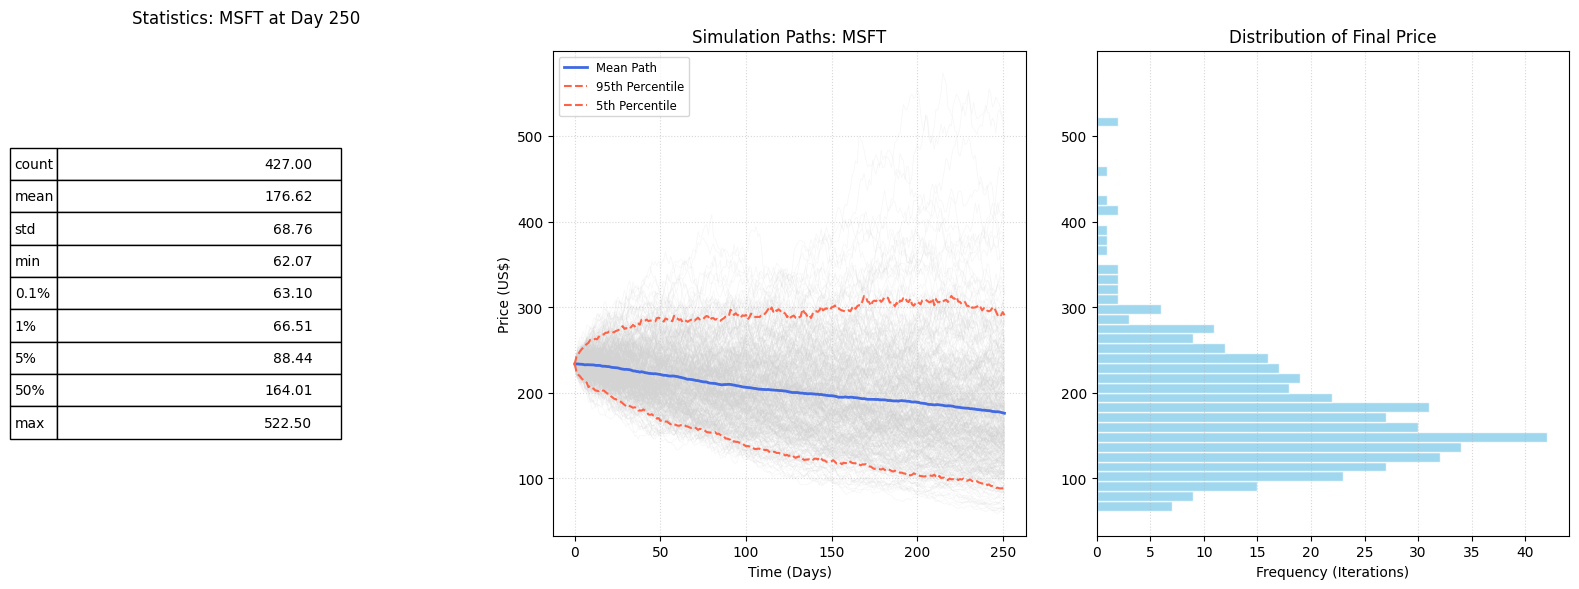

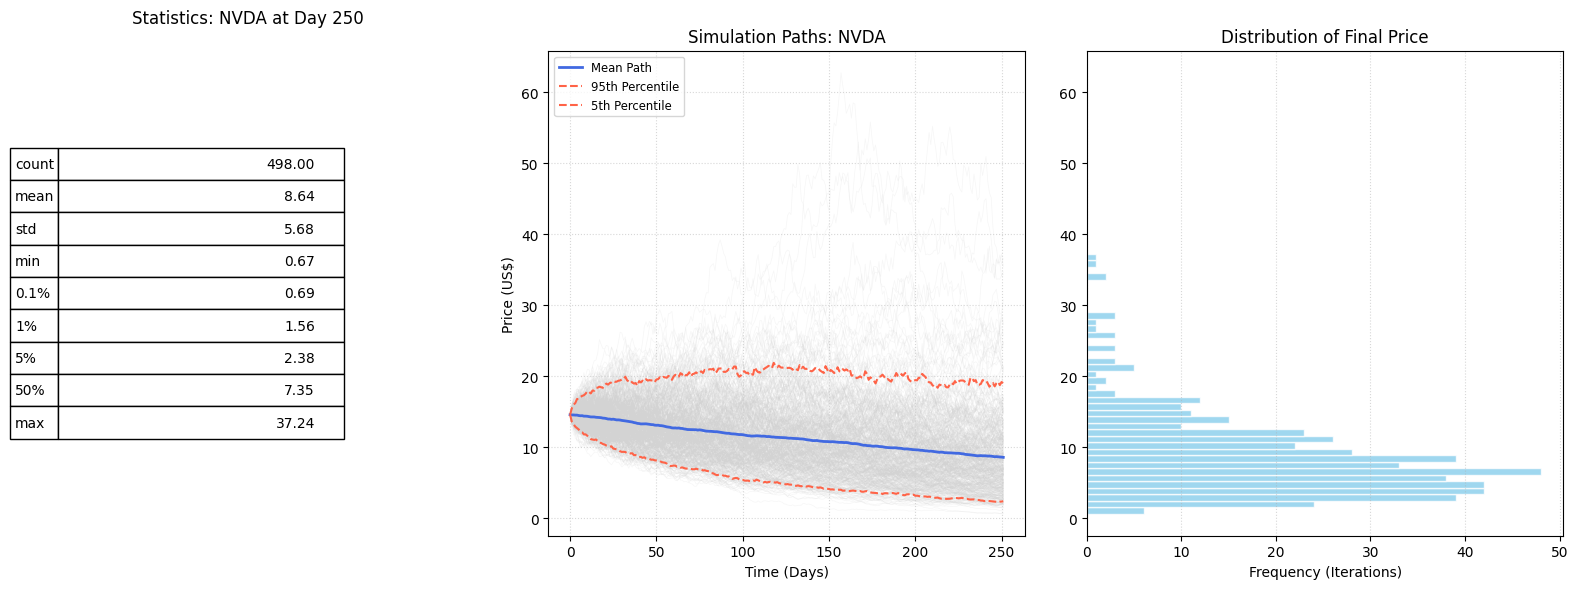

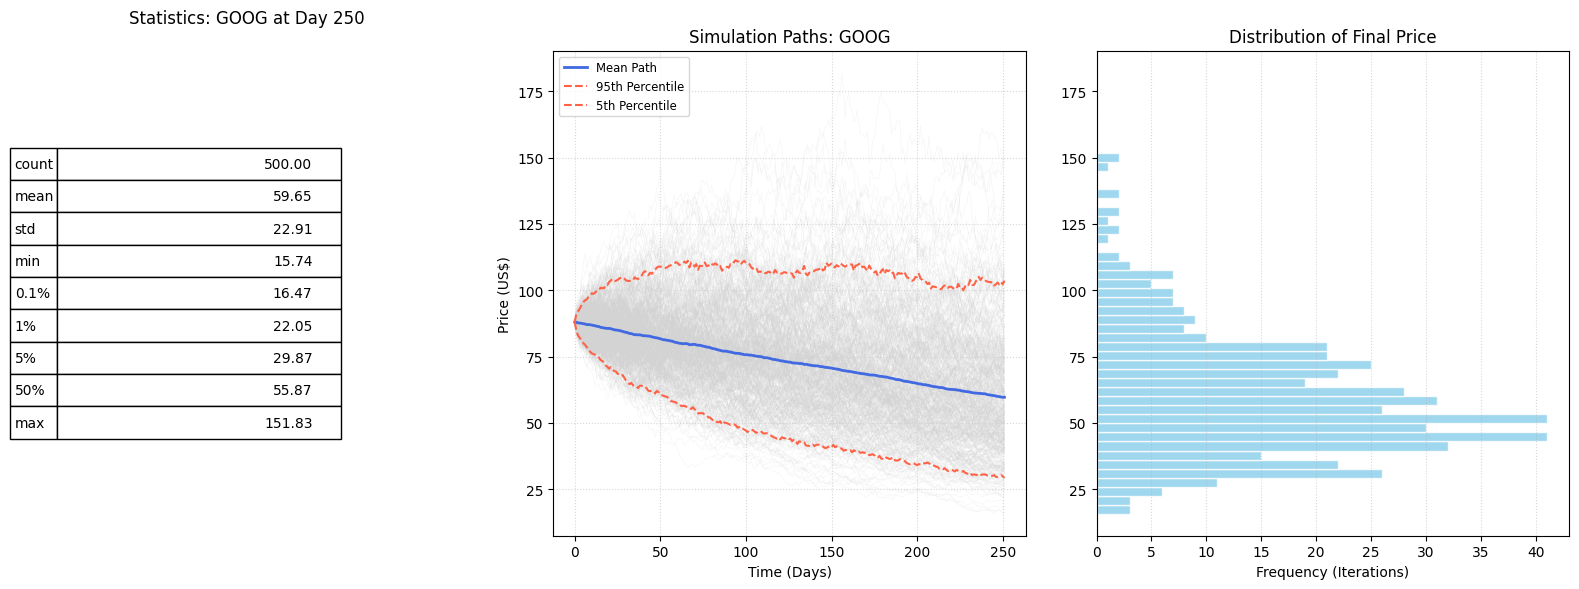

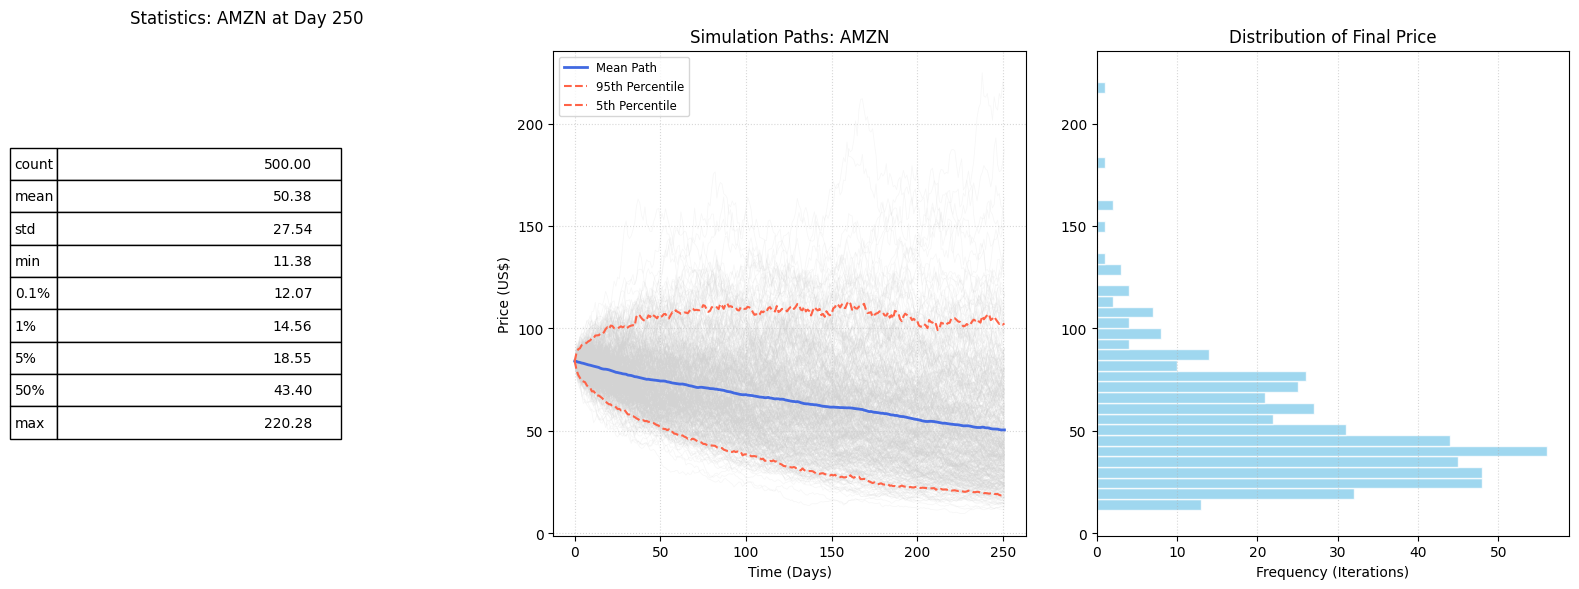

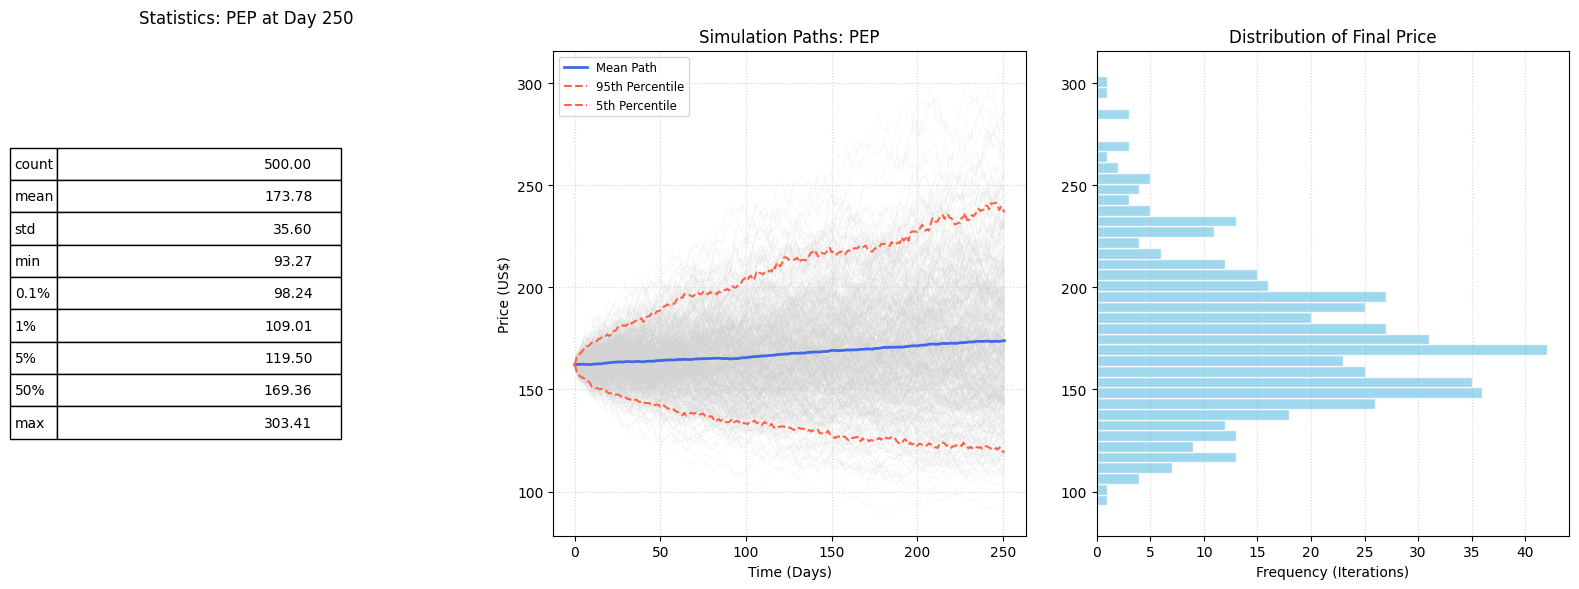

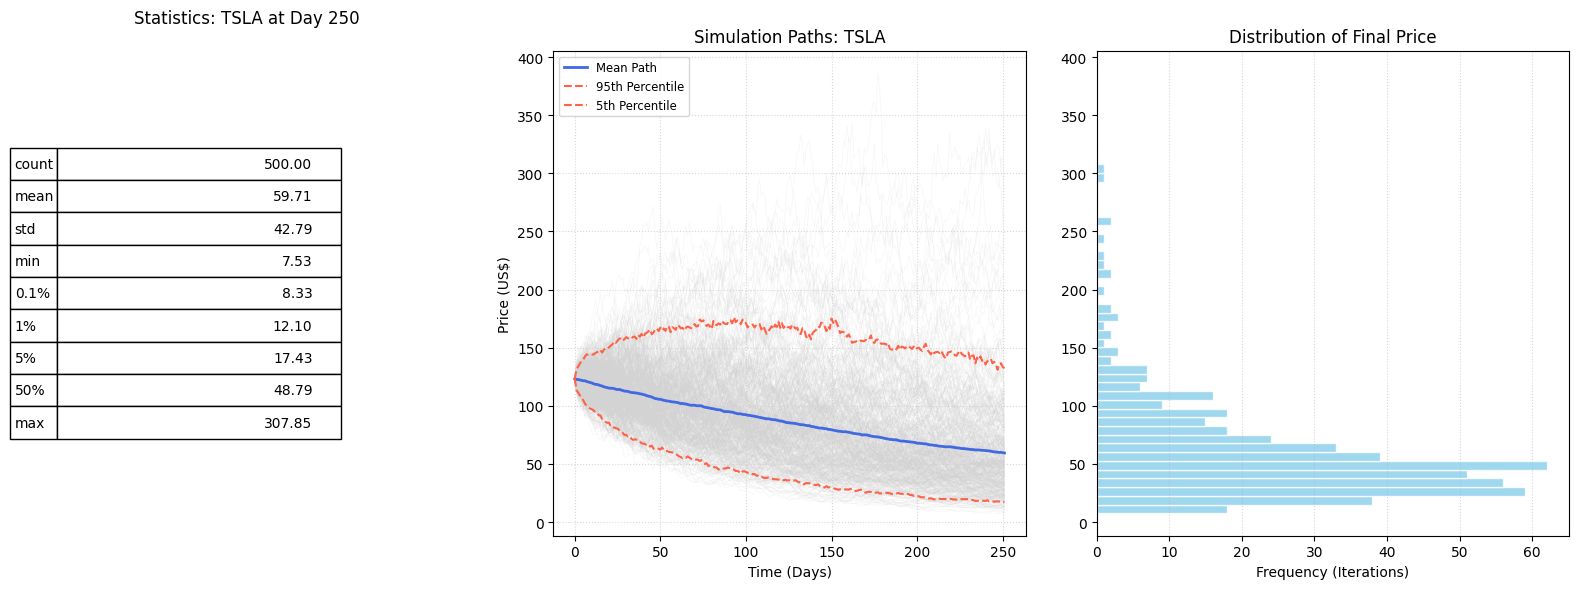

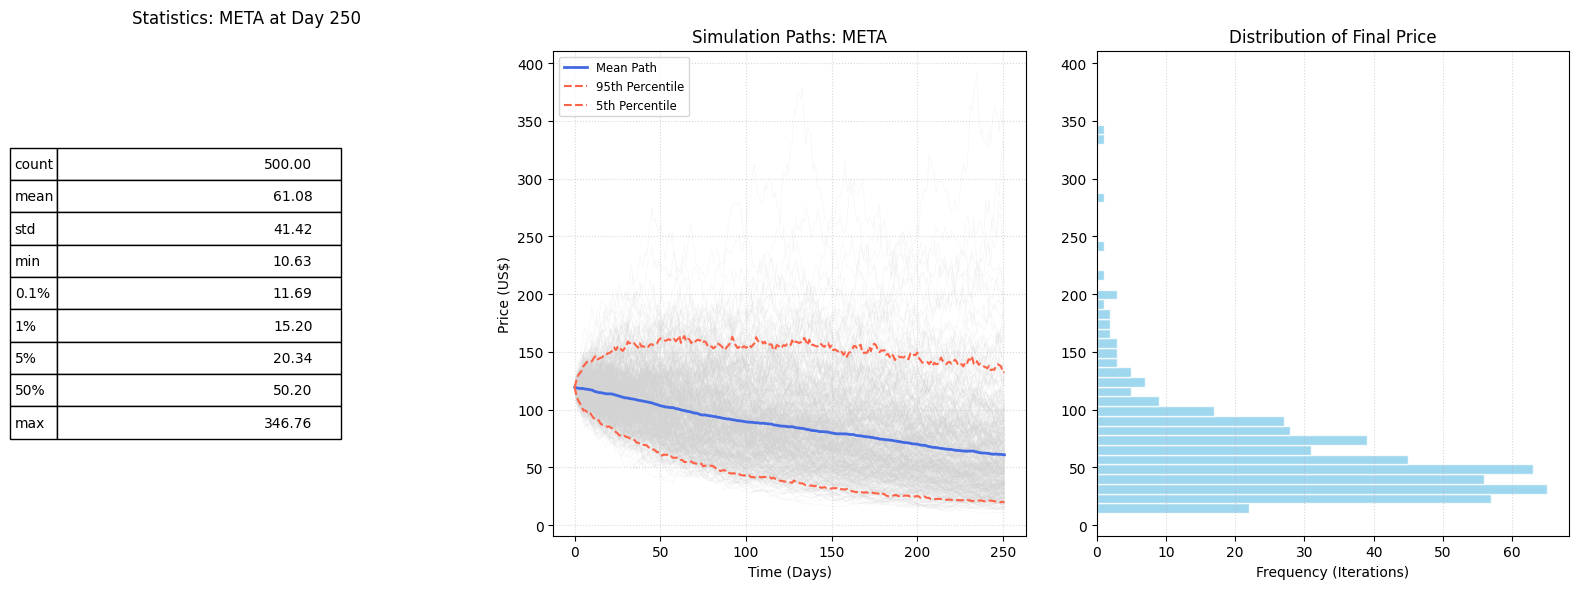

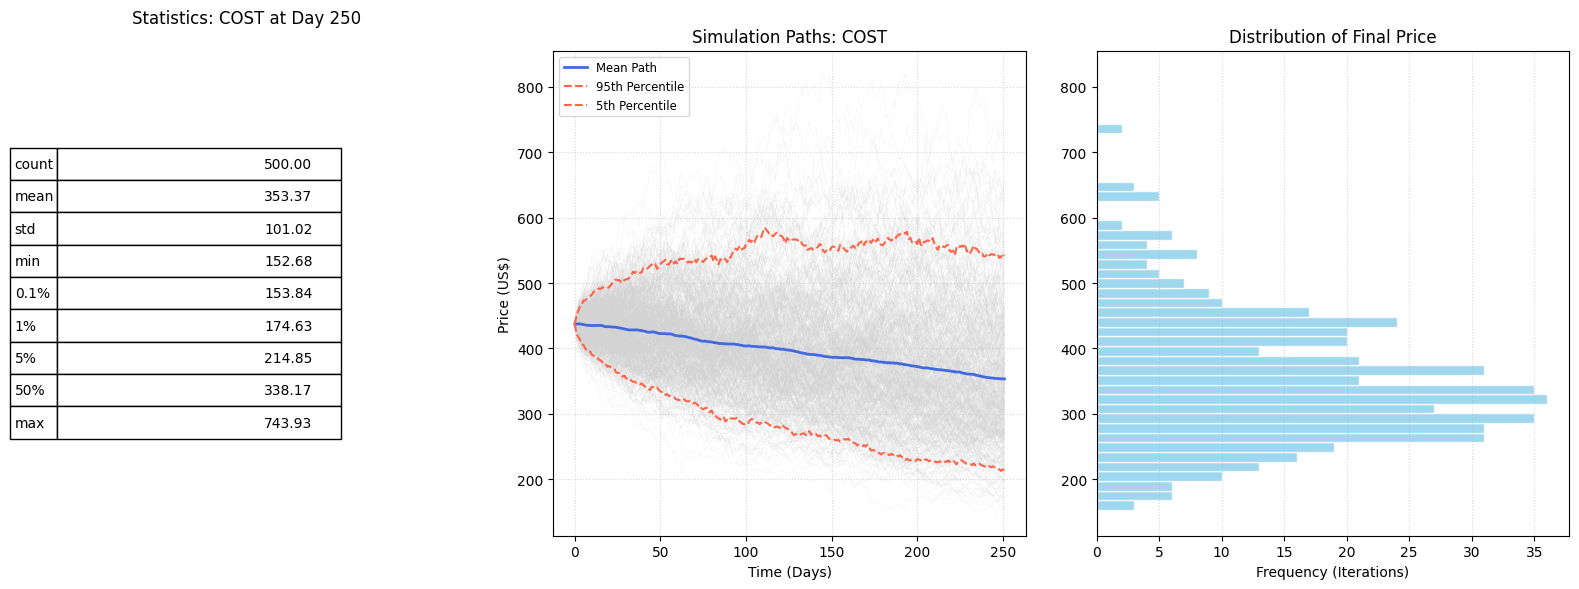

In [21]:
ticker_list = df.ticker.unique()

for t in ticker_list:
    plot_ticker(t,df)

In [1]:
import sys
print(sys.version)

3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]
